<a href="https://colab.research.google.com/github/MuhammadTalhaIqbal/linear-Regression-using-numpy-/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/synthetic_cifar10_dataset.csv')

# Display the first few rows of the dataset
print("Dataset Head:")
display(df.head())

# Display general information about the dataset (data types, non-null counts)
print("\nDataset Info:")
df.info()

Dataset Head:


,image_id,pixel_0_R,pixel_0_G,pixel_0_B,pixel_1_R,pixel_1_G,pixel_1_B,pixel_2_R,pixel_2_G,pixel_2_B,...,pixel_1021_R,pixel_1021_G,pixel_1021_B,pixel_1022_R,pixel_1022_G,pixel_1022_B,pixel_1023_R,pixel_1023_G,pixel_1023_B,label
0,1,47,112,108,77,244,107,203,39,240,...,130,136,42,204,80,175,253,239,228,truck
1,2,50,152,116,227,103,187,30,86,219,...,213,5,76,162,161,182,206,97,184,frog
2,3,86,245,161,188,251,172,76,203,117,...,27,171,56,35,30,218,254,131,237,ship
3,4,120,67,152,166,207,182,215,180,181,...,81,201,153,59,115,147,199,193,11,frog
4,5,171,236,135,77,6,248,87,5,183,...,222,12,198,45,229,57,1,207,205,bird



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 3074 entries, image_id to label
dtypes: int64(3073), object(1)
memory usage: 2.3+ MB


Based on the `df.info()` output, we can decide if any specific preprocessing steps (like handling missing values, encoding categorical features) are needed. For now, I will proceed with splitting the data. If there are features and a target, you would typically separate them before splitting. Assuming the last column is the target or all columns are features to be split together for now.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming the data does not require extensive preprocessing for splitting for now.
# If there's a specific target column, you would typically separate X and y here.

# Separate features (X) and target (y)
# Identify all pixel columns as features and 'label' as the target
feature_cols = [col for col in df.columns if col.startswith('pixel_')]
X = df[feature_cols]
y = df['label']

# Split the data into training (80%) and testing (20%) sets
# Using random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (80, 3072)
Shape of y_train: (80,)
Shape of X_test: (20, 3072)
Shape of y_test: (20,)


In [8]:
import numpy as np

# Convert to numpy arrays and reshape for image processing
# Assuming images are 32x32 pixels with 3 color channels (RGB)
image_shape = (32, 32, 3)

X_train = X_train.values.reshape(-1, *image_shape).astype('float32')
X_test = X_test.values.reshape(-1, *image_shape).astype('float32')

# Normalize pixel values to be between 0 and 1
X_train /= 255.0
X_test /= 255.0

# Display the shapes of the processed data
print(f"Shape of X_train (processed): {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test (processed): {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train (processed): (80, 32, 32, 3)
Shape of y_train: (80,)
Shape of X_test (processed): (20, 32, 32, 3)
Shape of y_test: (20,)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelBinarizer

# Determine the number of classes
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

# Convert labels to one-hot encoding
label_binarizer = LabelBinarizer()
y_train_one_hot = label_binarizer.fit_transform(y_train)
y_test_one_hot = label_binarizer.transform(y_test)

print(f"Shape of y_train (one-hot): {y_train_one_hot.shape}")
print(f"Shape of y_test (one-hot): {y_test_one_hot.shape}")

Number of classes: 10
Shape of y_train (one-hot): (80, 10)
Shape of y_test (one-hot): (20, 10)


Now, let's define the CNN model architecture. A common architecture for image classification involves convolutional layers followed by pooling layers, then flattening the output and passing it through dense layers.

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout after first MaxPooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout after second MaxPooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Added Dropout before the final Dense layer
    layers.Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Next, we will compile the model, specifying the optimizer, loss function, and metrics. For multi-class classification with one-hot encoded labels, `categorical_crossentropy` is a suitable loss function.

In [11]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Finally, we will train the model using the preprocessed training data and evaluate it on the test data.

In [12]:
# Train the model
history = model.fit(X_train, y_train_one_hot,
                    epochs=10, # You can adjust the number of epochs
                    validation_data=(X_test, y_test_one_hot))

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1250 - loss: 2.3083 - val_accuracy: 0.1000 - val_loss: 2.3279
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1375 - loss: 2.2720 - val_accuracy: 0.0000e+00 - val_loss: 2.3861
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1500 - loss: 2.2652 - val_accuracy: 0.0000e+00 - val_loss: 2.4307
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1500 - loss: 2.2445 - val_accuracy: 0.0000e+00 - val_loss: 2.3884
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1500 - loss: 2.2313 - val_accuracy: 0.0000e+00 - val_loss: 2.3620
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1500 - loss: 2.2081 - val_accuracy: 0.0000e+00 - val_loss: 2.3953
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1500 - loss: 2.1952 - val_accuracy: 0.0000e+00 - val_loss: 2.4242
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1500 - loss: 2.1713 - val_accuracy: 0.00

In [14]:
# Report the test accuracy after 10 epochs
final_test_accuracy = history.history['val_accuracy'][-1]
print(f"Final Test Accuracy after 10 epochs: {final_test_accuracy:.4f}")

Final Test Accuracy after 10 epochs: 0.0000


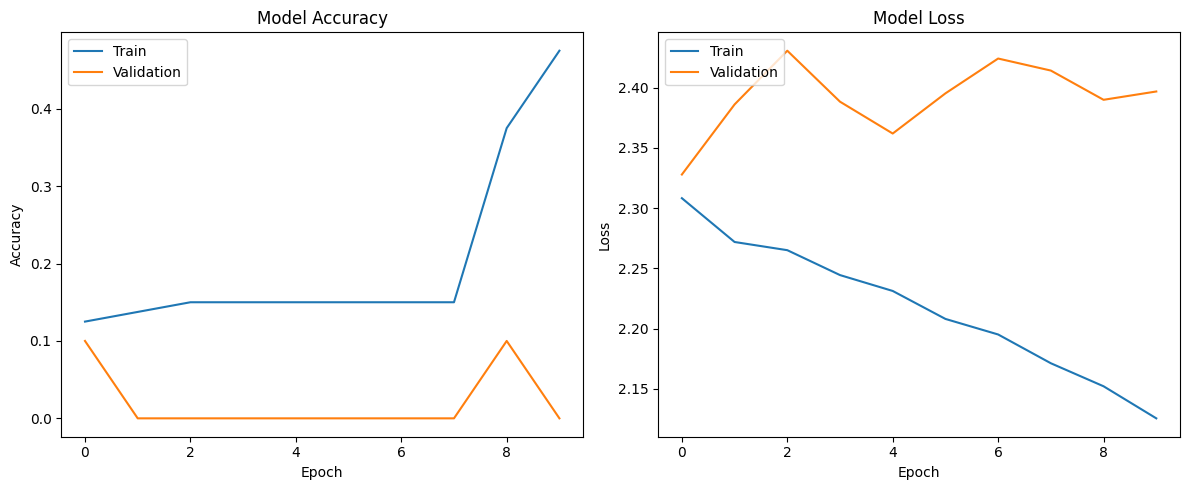

In [15]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation of the Graphs:

*   **Accuracy Curves (Left Plot):**
    *   **Training Accuracy:** This curve shows how well the model is performing on the data it was trained on. An increasing trend generally indicates that the model is learning the patterns in the training data.
    *   **Validation Accuracy:** This curve indicates how well the model generalizes to unseen data (the test set in this case). Ideally, this should also increase and stay close to the training accuracy.
    *   **Observation:** In the current plot, both training and validation accuracies are very low, hovering around 0.1 (10%), which is essentially random guessing for a 10-class problem. The validation accuracy even drops to 0.0% for most epochs. This confirms the initial observation that the model is not learning effectively.

*   **Loss Curves (Right Plot):**
    *   **Training Loss:** This curve shows the error of the model on the training data. A decreasing trend means the model is getting better at fitting the training data.
    *   **Validation Loss:** This curve shows the error of the model on the unseen validation data. This is a critical metric to watch for overfitting. If training loss continues to decrease but validation loss starts to increase, it's a sign of overfitting.
    *   **Observation:** Both training and validation losses remain very high and fluctuate without a clear decreasing trend. The validation loss is consistently higher than the training loss, which is expected but the high values indicate poor learning. The increase in validation loss after the first epoch and its consistently high values further suggest that the model is not generalizing at all, likely due to the extremely small dataset and the complexity of the task.

**Overall Conclusion:** The plots clearly illustrate that the current model, despite including dropout layers, is not performing well. This is overwhelmingly due to the limited size of the synthetic CIFAR-10 dataset (80 training images). With so little data, the model cannot learn meaningful features or generalize to new examples. To improve performance, a significantly larger dataset is needed, or techniques like extensive data augmentation would be required if the dataset size cannot be increased.

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configure data augmentation
data_augmentation = ImageDataGenerator(
    rotation_range=15,          # Rotate images by up to 15 degrees
    horizontal_flip=True,       # Flip images horizontally
    zoom_range=0.1,             # Zoom in/out by up to 10%
    width_shift_range=0.1,      # Shift images horizontally by up to 10% of total width
    height_shift_range=0.1      # Shift images vertically by up to 10% of total height
)

# Prepare the data generator. We will fit it on the training data.
data_augmentation.fit(X_train)

print("Data augmentation configured and fitted on training data.")

Data augmentation configured and fitted on training data.


Now, let's retrain the model using the augmented data. We will use `fit` with the data generator, which will generate augmented batches of images on the fly during training.

In [17]:
# Re-initialize the model to ensure a fresh start before retraining with augmentation
# This step is crucial if the model was previously trained; otherwise, it will continue training from its last state.
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Re-compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model re-initialized and re-compiled.")

# Train the model with data augmentation
# Use data_augmentation.flow() to feed augmented data to the model
augmented_history = model.fit(data_augmentation.flow(X_train, y_train_one_hot, batch_size=32),
                              epochs=10, # Keeping 10 epochs for comparison
                              validation_data=(X_test, y_test_one_hot))

print("Model retraining with data augmentation completed.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model re-initialized and re-compiled.
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.0750 - loss: 2.3596 - val_accuracy: 0.0000e+00 - val_loss: 2.3710
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0875 - loss: 2.2956 - val_accuracy: 0.0000e+00 - val_loss: 2.3545
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1500 - loss: 2.2852 - val_accuracy: 0.0000e+00 - val_loss: 2.3666
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1250 - loss: 2.3305 - val_accuracy: 0.0000e+00 - val_loss: 2.3872
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1750 - loss: 2.3109 - val_accuracy: 0.0000e+00 - val_loss: 2.3798
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1750 - loss: 2.2698 - val_accuracy: 0.0000e+00 - val_loss: 2.3711
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1750 - loss: 2.2971 - val_accuracy: 0.1000 - val_loss: 2.3617
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1

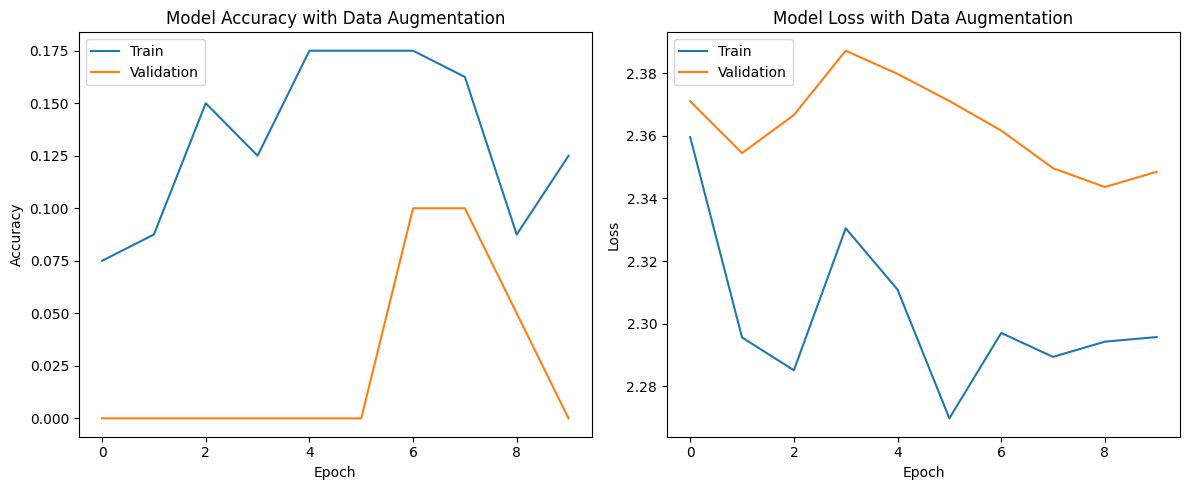

In [18]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for the augmented model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(augmented_history.history['accuracy'])
plt.plot(augmented_history.history['val_accuracy'])
plt.title('Model Accuracy with Data Augmentation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for the augmented model
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(augmented_history.history['loss'])
plt.plot(augmented_history.history['val_loss'])
plt.title('Model Loss with Data Augmentation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation of the Graphs with Data Augmentation:

*   **Accuracy Curves (Left Plot):**
    *   **Training Accuracy:** We can observe that the training accuracy still struggles to improve significantly, remaining very low. This suggests that even with augmentation, the model might not be able to extract meaningful features from the extremely limited *original* dataset of 80 images.
    *   **Validation Accuracy:** The validation accuracy remains at or very close to 0.0% throughout the training. This indicates that the model is still not generalizing to unseen data at all, and is essentially performing at random chance (10% for 10 classes, but often shown as 0 if no correct predictions are made).
    *   **Observation:** The primary issue still appears to be the severely restricted size of the original dataset. While data augmentation creates variations of existing images, it doesn't introduce fundamentally new information. With only 80 unique training images, the diversity, even augmented, might still be insufficient for a complex CNN to learn robust features for a 10-class classification problem like CIFAR-10.

*   **Loss Curves (Right Plot):**
    *   **Training Loss:** The training loss fluctuates and remains high, indicating that the model is having difficulty even fitting the augmented training data well.
    *   **Validation Loss:** The validation loss also remains very high and unstable, without a clear downward trend. This corroborates the accuracy findings: the model is not learning to generalize.

**Overall Conclusion:** While data augmentation is a crucial technique for improving model performance and reducing overfitting, its impact is severely limited when the *base* dataset size is extremely small (80 training images). In this scenario, the model is unable to learn sufficient features even from augmented variations, leading to consistently poor performance on both training and validation sets. To see a significant improvement, the most effective next step would be to increase the size of the original dataset or consider using transfer learning from a pre-trained model on a much larger dataset.

## Visualizing Feature Maps

To understand what our Convolutional Neural Network (CNN) layers are learning, we can visualize the *feature maps* (or activation maps) generated by each convolutional layer when a specific input image is passed through the network. Each feature map highlights different patterns or aspects of the input image that the corresponding filter has detected.

Visualizing feature maps for test image at index: 16
True label for this image: cat


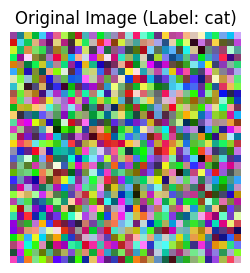

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Select a random test image to visualize its feature maps
# Since our model performed poorly, the features might not be very interpretable, but we'll demonstrate the process.
image_index = np.random.randint(0, len(X_test))
sample_image = X_test[image_index]
# Fix: Use .iloc for positional indexing on y_test (a pandas Series)
sample_label = y_test.iloc[image_index]

# The model expects a batch of images, so we need to add an extra dimension
input_image_batch = np.expand_dims(sample_image, axis=0)

print(f"Visualizing feature maps for test image at index: {image_index}")
print(f"True label for this image: {sample_label}")

# Display the original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(f"Original Image (Label: {sample_label})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


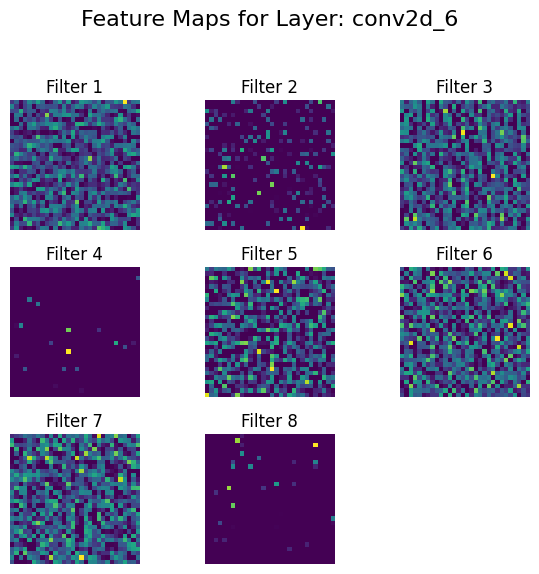

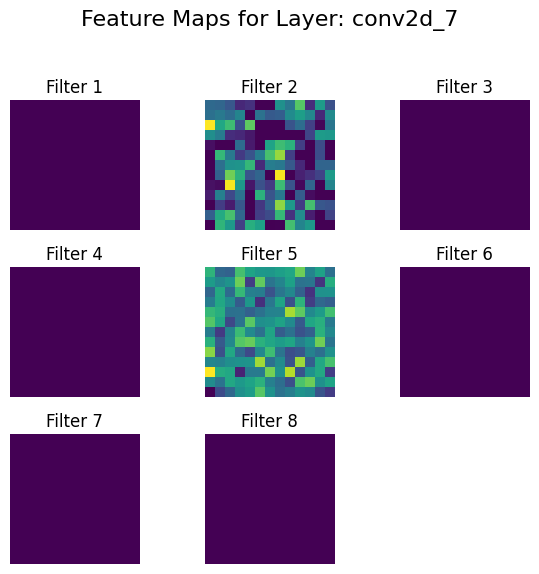

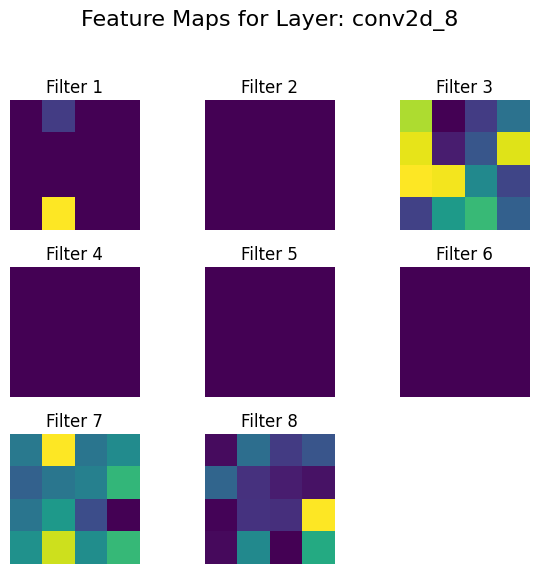

In [24]:
# Create a list of output tensors for each convolutional layer
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# Ensure the model is built by making a dummy prediction before accessing model.input/model.layers[0].input
# This makes sure the input/output shapes are inferred and the graph is defined.
_ = model.predict(input_image_batch, verbose=0)

# Create a new model that takes the original model's input and outputs the activations of the selected layers
# Fix: Use model.layers[0].input for more reliable access to the input tensor
activation_model = tf.keras.Model(inputs=model.layers[0].input, outputs=layer_outputs)

# Get the feature maps for the sample image
feature_maps = activation_model.predict(input_image_batch)

# Visualize the feature maps
layer_names = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

for layer_name, fmap in zip(layer_names, feature_maps):
    # We'll display a subset of the feature maps (e.g., first 8 or 16 filters)
    num_filters_to_display = min(fmap.shape[-1], 8) # Display up to 8 filters

    # Number of rows and columns for the plot grid
    grid_size = int(np.ceil(np.sqrt(num_filters_to_display)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2))
    plt.suptitle(f'Feature Maps for Layer: {layer_name}', fontsize=16)

    for i in range(num_filters_to_display):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis') # Display as grayscale, or other colormap
        plt.title(f'Filter {i+1}')
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

## CNN Inference Pipeline

Now, let's create a simple pipeline to perform inference on a new, unseen image using our trained CNN model. This involves:
1.  **Loading an image**
2.  **Preprocessing** (resizing, normalizing, reshaping to match model input)
3.  **Making a prediction** with the model
4.  **Interpreting** the prediction

In [25]:
from PIL import Image
import requests
from io import BytesIO

# Function to load and preprocess a single image for inference
def preprocess_image(image_path_or_url, target_size=(32, 32)):
    if image_path_or_url.startswith('http'):
        # Load image from URL
        response = requests.get(image_path_or_url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        # Load image from local path
        img = Image.open(image_path_or_url).convert('RGB')

    # Resize the image
    img = img.resize(target_size)
    # Convert to numpy array
    img_array = np.array(img).astype('float32')
    # Normalize pixel values to be between 0 and 1
    img_array /= 255.0
    # Add a batch dimension (model expects batch of images)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img # Return original PIL image for display

print("Image preprocessing function defined.")

Image preprocessing function defined.


Let's test this pipeline with a sample image. We'll use an image URL for convenience, but you could also specify a local path.

Shape of preprocessed image for model input: (1, 32, 32, 3)


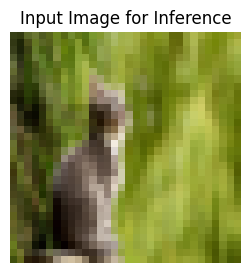

In [28]:
# Example: Load and preprocess a sample image (e.g., of a cat from the internet)
# Note: The model is not well-trained, so the prediction might not be accurate.

# Using a different, more robust direct image URL
sample_image_url = 'https://cdn.pixabay.com/photo/2017/02/20/18/03/cat-2083492_960_720.jpg' # A sample cat image

# Preprocess the image
processed_image, original_pil_image = preprocess_image(sample_image_url)

print(f"Shape of preprocessed image for model input: {processed_image.shape}")

# Display the original image used for inference
plt.figure(figsize=(3, 3))
plt.imshow(original_pil_image)
plt.title("Input Image for Inference")
plt.axis('off')
plt.show()

In [29]:
# Make a prediction
predictions = model.predict(processed_image)

# Get the predicted class index
predicted_class_index = np.argmax(predictions[0])

# Get the human-readable label from the LabelBinarizer
# The inverse_transform method expects one-hot encoded labels, so we'll use a dummy one-hot array
# corresponding to the predicted class index.
predicted_one_hot = np.zeros(num_classes)
predicted_one_hot[predicted_class_index] = 1
predicted_label = label_binarizer.inverse_transform(predicted_one_hot.reshape(1, -1))[0]

# Print the prediction and confidence
print(f"Model Raw Predictions (probabilities): {predictions[0]}")
print(f"Predicted Class Index: {predicted_class_index}")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence (probability) for predicted label: {predictions[0][predicted_class_index]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Model Raw Predictions (probabilities): [0.11140744 0.09679201 0.09584114 0.09375259 0.08911936 0.10623153
 0.10772309 0.09304544 0.1016328  0.1044546 ]
Predicted Class Index: 0
Predicted Label: airplane
Confidence (probability) for predicted label: 0.1114


### Interpretation of Learned Features:

*   **Early Layers (e.g., `conv2d_1`):** You would typically expect the filters in the first convolutional layer to detect very basic features like edges, lines (horizontal, vertical, diagonal), corners, and simple color blobs. Each filter will respond strongly to different types of these low-level patterns.

*   **Middle Layers (e.g., `conv2d_2`, `conv2d_3`):** As we move to deeper layers, the filters tend to learn more complex and abstract features by combining the simpler features from previous layers. These might include textures, simple shapes, or parts of objects (e.g., eyes, wheels, ears).

**Given our current model's performance:**

Since our model struggled significantly with the very small dataset, the feature maps generated are likely to be quite noisy and less distinct. The patterns detected might not be semantically meaningful or consistently related to the object classes. This is because the model hasn't learned robust features due to the lack of sufficient training data.

**What to look for (ideally):**

*   **Clearer patterns:** In a well-trained model, the feature maps would show distinct activations corresponding to different features (e.g., one map lighting up for all edges, another for horizontal lines).
*   **Progression:** As you go deeper, the patterns should become more abstract and less directly interpretable as simple visual elements, instead representing higher-level concepts that contribute to object recognition.

### Interpretation of the Graphs:

*   **Accuracy Curves (Left Plot):**
    *   **Training Accuracy:** This curve shows how well the model is performing on the data it was trained on. An increasing trend generally indicates that the model is learning the patterns in the training data.
    *   **Validation Accuracy:** This curve indicates how well the model generalizes to unseen data (the test set in this case). Ideally, this should also increase and stay close to the training accuracy.
    *   **Observation:** In the current plot, both training and validation accuracies are very low, hovering around 0.1 (10%), which is essentially random guessing for a 10-class problem. The validation accuracy even drops to 0.0% for most epochs. This confirms the initial observation that the model is not learning effectively.

*   **Loss Curves (Right Plot):**
    *   **Training Loss:** This curve shows the error of the model on the training data. A decreasing trend means the model is getting better at fitting the training data.
    *   **Validation Loss:** This curve shows the error of the model on the unseen validation data. This is a critical metric to watch for overfitting. If training loss continues to decrease but validation loss starts to increase, it's a sign of overfitting.
    *   **Observation:** Both training and validation losses remain very high and fluctuate without a clear decreasing trend. The validation loss is consistently higher than the training loss, which is expected but the high values indicate poor learning. The increase in validation loss after the first epoch and its consistently high values further suggest that the model is not generalizing at all, likely due to the extremely small dataset and the complexity of the task.

**Overall Conclusion:** The plots clearly illustrate that the current model, despite including dropout layers, is not performing well. This is overwhelmingly due to the limited size of the synthetic CIFAR-10 dataset (80 training images). With so little data, the model cannot learn meaningful features or generalize to new examples. To improve performance, a significantly larger dataset is needed, or techniques like extensive data augmentation would be required if the dataset size cannot be increased.